# Redundancia en un robot plano 3R

In [ ]:
# Para correr en Colab
%pip install roboticstoolbox-python
%pip install numpy==1.26.4 --force-reinstall

# Nota importante: da error porque un montón de bibliotecas de Colab dependen de numpy 2, 
# pero como no se utilizan no importa. 
#
# Cuando termina de ejecutarse la celda, pide reiniciar el kernel (aparece un botón bien evidente)
# Luego de reiniciar correr las celdas siguientes

In [9]:
import numpy as np
import roboticstoolbox as rtb
from roboticstoolbox import DHRobot, RevoluteDH
import spatialmath as sm
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from IPython.display import HTML


np.set_printoptions(precision=3, suppress=True)

## Definición del robot y funciones de animación 2D

In [121]:
#% Preparo el modelo de un doble péndulo
class Planar3R(DHRobot):
    """
    Robot 3R planar simple, orientado a prácticas:

    - Usa tres eslabones con parámetros DH
    """
    def __init__(self):    
        # Definición de los enlaces usando parámetros DH
        eje1 = RevoluteDH(a=1,alpha=0)
        eje2 = RevoluteDH(a=1,alpha=0)  
        eje3 = RevoluteDH(a=0.5,alpha=0)  
        self.Ts = 10E-3  

        # Crear la estructura del robot: llamo al constructor de DHRobotGT
        super().__init__([eje1, eje2, eje3], name='Planar3R')

    def manipulability_2D(self,q):
        J = self.jacob0(q)[:2,:]
        return np.sqrt(np.linalg.det(J @ J.T))

    def plot_curves(self,q_samples,w_samples=None,label="Manipulabilidad"):
        t = np.arange(q_samples.shape[0]) * robot.Ts

        fig, ax = plt.subplots(2, 1, figsize=(6,4))
        ax[0].plot(t, q_samples*180/np.pi, lw=2, label=[r'$q_1$',r'$q_2$',r'$q_3$'])
        ax[0].set_ylabel('Ángulo [°]')
        ax[0].legend()

        dth = np.diff(q_samples, axis=0) / robot.Ts
        ax[1].plot(t[:-1], dth*180/np.pi, lw=2, label=[r'$\dot{q}_1$',r'$\dot{q}_2$',r'$\dot{q}_3$'])
        ax[1].set_xlabel('t [s]')
        ax[1].set_ylabel('Velocidad [°/s]')
        ax[1].legend()        
        plt.tight_layout()
        plt.show()

        if w_samples is not None:
            plt.figure(figsize=(6,3))
            plt.plot(t, w_samples, lw=2)
            plt.ylabel(label)
            plt.xlabel('t [s]')
            #plt.legend()
            plt.tight_layout()
            plt.show()
            
        
    def animate(self, q, frame_rate=25, video_file_name='', show_ellipse=False):
        """
        Crea una animación del doble péndulo (ideal para notebooks).

        - Ajusta número de pasos por frame para respetar self.Ts y el frame_rate pedido.
        - Devuelve HTML con el video embebido (ani.to_html5_video()).

        Notas:
         - Renderiza en 2D XY y trazas del extremo. Pensado para demostraciones.
        """
        # ----------------------------------------------------
        # 1. Parámetros y optimización de frames
        # ----------------------------------------------------
        VIDEO_FPS = frame_rate
        
        # Cuántos pasos de simulación hay que saltar para aproximar el FPS pedido
        PASOS_POR_FRAME = max(1, int(1 / (self.Ts * (VIDEO_FPS)))) 

        n_frames_simulacion = len(q)
        indices_a_animar = np.arange(0, n_frames_simulacion, PASOS_POR_FRAME)
        print(f"Animando {len(indices_a_animar)} frames")
        interval_ms = 1000 / VIDEO_FPS

        # -----------------------------------------------
        # Preparación del gráfico y de los datos iniciales
        # -----------------------------------------------        
        fig, ax = plt.subplots(figsize=(6, 6))
        L = self.a[0]+self.a[1]  # longitud total aproximada para ejes
        ax.set_xlim(-L*1.1, L*1.1) 
        ax.set_ylim(-L*1.1, L*1.1)
        ax.set_aspect('equal') # importante para evitar distorsiones
        ax.grid(True)

        # Línea que representa los dos eslabones y marcadores de masas
        line, = ax.plot([], [], 'o-', lw=3, markersize=8)
        # Trayectoria actual 
        path, = ax.plot([], [], 'b:', lw=1, alpha=0.5, label='Trayectoria')
        # Elipsoide de manipulabilidad
        path_ellipse, = ax.plot([], [], 'g-', lw=1, alpha=1, label='Elipsoide')

        # Marcar inicio y destino sobre el plano XY
        P = self.fkine(q[0]).t
        ax.plot(P[0],P[1],'bo',lw=2,label='Inicio')
        P = self.fkine(q[-1]).t
        ax.plot(P[0],P[1],'bx',lw=2,label='Destino')
        ax.legend(loc='upper right')

        # -----------------------------------------------
        # Funciones para la animación (init y update)
        # -----------------------------------------------
        def init():
            # Pone el objeto gráfico en el estado inicial (vacío)
            line.set_data([], [])
            return line,

        def update_plot(frame):
            """
            Actualiza la posición del robot para el índice 'frame'.

            - Obtiene transformaciones con fkine_all (lista de SE3 para eslabones).
            - Construye arrays x,y para las líneas que une origen-P1-P2-P3.
            - Actualiza trazas si corresponde.
            """
            q_actual = q[frame] 
            A = self.fkine_all(q_actual)

            # Transformaciones: A[1] es base->joint1, A[2] es base->extremo2
            P3 = A[3].t
            P2 = A[2].t
            P1 = A[1].t

            # Puntos a dibujar (Origen, articulación intermedia, extremo)
            x = [0, P1[0], P2[0], P3[0]]
            y = [0, P1[1], P2[1], P3[1]]
            line.set_data(x, y)

            if show_ellipse:
                J = self.jacob0(q_actual)[:2,:]
                U,S,Vt = np.linalg.svd(J)

                theta = np.linspace(0, 2*np.pi, 50)
                circle = np.vstack((np.cos(theta), np.sin(theta)))  # círculo unitario
                ellipse = U @ np.diag(S)/2.0 @ circle
                x_ellipse = ellipse[0, :] + P3[0]
                y_ellipse = ellipse[1, :] + P3[1]
                path_ellipse.set_data(x_ellipse, y_ellipse)
            
            # Construye la trayectoria realizada hasta el frame actual
            q_historial = q[:frame + 1, :]            
            T_historial_P2 = self.fkine(q_historial)
            x_path = np.array([T.t[0] for T in T_historial_P2]).ravel()
            y_path = np.array([T.t[1] for T in T_historial_P2]).ravel()
            path.set_data(x_path, y_path)

            return line, path

        # -----------------------------------------------
        # Creación del objeto FuncAnimation y salida
        # -----------------------------------------------
        n_frames = len(q)
        ani = FuncAnimation(
            fig, 
            update_plot, 
            frames=indices_a_animar, 
            init_func=init, 
            blit=True, 
            interval=interval_ms,
            repeat=False 
        )

        # Guardado opcional (ffmpeg debe estar instalado si se pide mp4)
        if len(video_file_name)>0:
            ani.save(video_file_name, writer='ffmpeg', fps=VIDEO_FPS)

        # Cerrar la figura para que no se muestre dos veces en notebooks
        plt.close(fig)
        return HTML(ani.to_html5_video())         

robot = Planar3R()
print(robot)


DHRobot: Planar3R, 3 joints (RRR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │   1 │ 0.0° │
│  q2 │  0 │   1 │ 0.0° │
│  q3 │  0 │ 0.5 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘



## Movimiento cartesiano sin redundancia

El robot plano 3R tiene 3 grados de libertad en el espacio de operación (px, py rotZ)

In [95]:
# Defino los puntos de la trayectoria de prueba
pose_ini = sm.SE3().Trans(-0.5, 0.5, 0)
pose_fin = sm.SE3().Trans(0.5, 0.5, 0)

q_ini = robot.ikine_LM(pose_ini).q
print("q_inicial: ", q_ini)
print("Verificación POSE inicial\n",robot.fkine(q_ini))

# Calculo la cantidad de pasos para llegar al objetivo en Td segundos
Td = 1
N = round(Td / robot.Ts)

q_inicial:  [-2.628 -1.955 -1.7  ]
Verificación POSE inicial
    1        -1.365e-07  0        -0.5       
   1.365e-07  1         0         0.5       
   0         0         1         0         
   0         0         0         1         



Verificación POSE final alcanzada
    1        -9.059e-09  0         0.5       
   9.059e-09  1         0         0.4999    
   0         0         1         0         
   0         0         0         1         



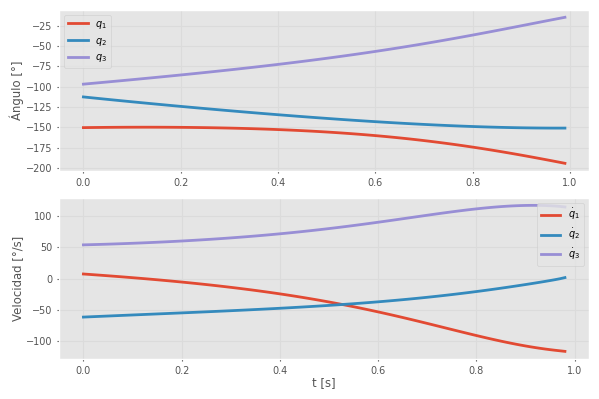

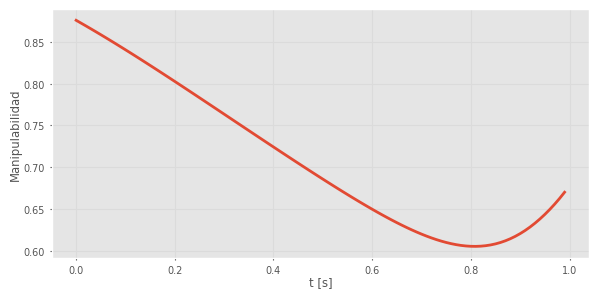

Animando 25 frames


In [122]:
q_samples = []
p_samples = []
w_samples = []
pos_fin = pose_fin.t[0:2]
rot_fin,_ = sm.SO3(pose_fin.R).angvec()
q = q_ini
for i in range(N):
    pose_act = robot.fkine(q)
    pos_act = pose_act.t[0:2]
    rot_act,_ = sm.SO3(pose_act.R).angvec()

    deltaX = np.hstack((pos_fin - pos_act,rot_fin-rot_act))
    dX = deltaX/(N-i)

    # Me quedo con las filas del  Jacobiano que dan vx, vy, wz
    J = robot.jacob0(q)[[0, 1, 5], :]

    # pseudoinversa
    dq = np.linalg.pinv(J) @ dX

    # incremento posición articular
    q = q + dq

    w_samples.append(robot.manipulability_2D(q))
    q_samples.append(q.copy())
    p_samples.append(pos_act.copy())

print("Verificación POSE final alcanzada\n",robot.fkine(q))

w_samples = np.array(w_samples)
q_samples = np.array(q_samples)
p_log = np.array(p_samples)

robot.plot_curves(q_samples,w_samples)
robot.animate(q_samples,show_ellipse=True)

## Movimiento cartesiano con redundancia 

Se puede considerar el problema de posición, de manera que los tres ejes actuados determinen la ubicación del origen de la terna 3.

En este caso no se controla la orientación del último eslabón

### Caso 1. Movimiento a máxima velocidad
Se busca aprovechar la redundancia para que los ejes recorran el menor camino.

Notar que en la simulación se mantiene constante el tiempo deseado del movimiento.

Verificación POSE final alcanzada
    0.8017    0.5977    0         0.5       
  -0.5977    0.8017    0         0.4999    
   0         0         1         0         
   0         0         0         1         



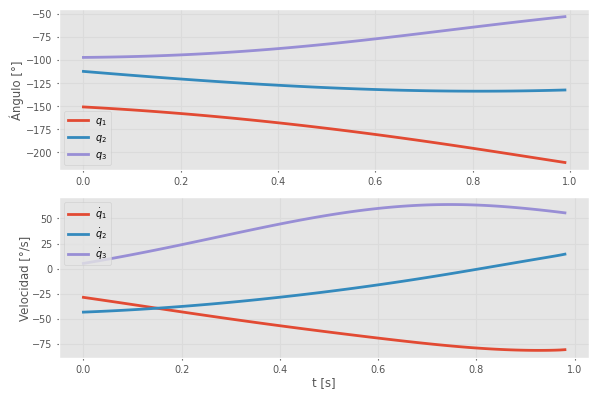

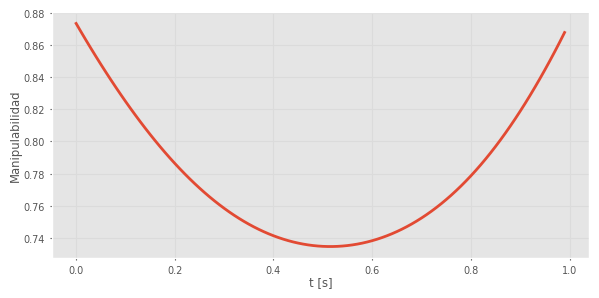

Animando 25 frames


In [123]:
# La trayectoria de prueba es la misma

q_samples = []
p_samples = []
w_samples = []
pos_fin = pose_fin.t[0:2]
q = q_ini
for i in range(N):
    pose_act = robot.fkine(q)
    pos_act = pose_act.t[0:2]

    deltaX = pos_fin - pos_act
    dX = deltaX/(N-i)

    # Me quedo con las filas del  Jacobiano que dan vx, vy, wz
    J = robot.jacob0(q)[[0, 1], :]

    # pseudoinversa
    dq = np.linalg.pinv(J) @ dX

    # incremento posición articular
    q = q + dq

    w_samples.append(robot.manipulability_2D(q))
    q_samples.append(q.copy())
    p_samples.append(pos_act.copy())

print("Verificación POSE final alcanzada\n",robot.fkine(q))

q_samples = np.array(q_samples)
w_samples = np.array(w_samples)
p_log = np.array(p_samples)

robot.plot_curves(q_samples,w_samples)
robot.animate(q_samples,show_ellipse=True)

## Caso 2. Movimiento con máxima manipulabilidad

Verificación POSE final alcanzada
   -1         3.363e-09  0        -0.5       
  -3.363e-09 -1         0        -1.676e-09  
   0         0         1         0         
   0         0         0         1         



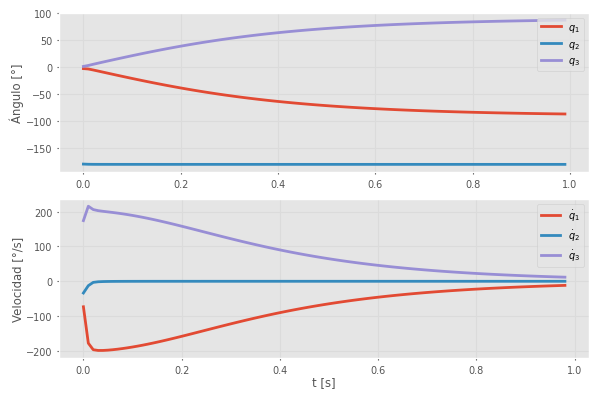

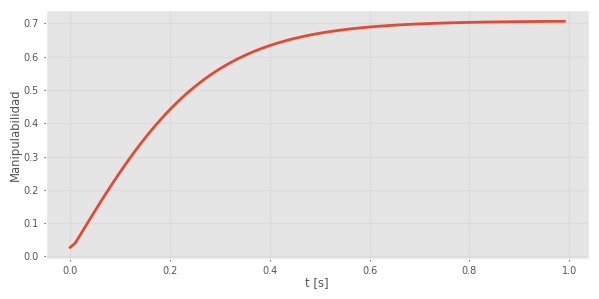

Animando 25 frames


In [124]:
# Vamos a movernos al mismo punto para observar la mejora en la manipulabilidad
# Para esto definimos el vector de diseño en el sentido del gradiente de la manipulabilidad  

from scipy.optimize import approx_fprime

alpha = 0.1

q_samples = []
p_samples = []
w_samples = []

# Ejemplo
# La trayectoria que se venía trabajando no muestra una clara diferencia
#pos_fin = pose_fin.t[0:2]
#q = q_ini

# Otro ejemplo (muy extremo!)
#q = [np.pi,0,np.pi]
#pos_fin = robot.fkine([0,0,np.pi]).t[0:2]

# Otro ejemplo (descomentar)
# Mantengo el punto, pero busco una configuración con mejor manipulabilidad
#pos_fin = pose_ini.t[0:2]
#q = q_ini

# Otro ejemplo (descomentar)
# Arranco de una configuración "incomoda" donde todos los ejes producen movimiento solo en una dirección cartesiana
# y busco mantener el punto pero mejorando la manipulabilidad
q = [0,-np.pi,0]
pos_fin = robot.fkine(q).t[0:2]

N = 100
for i in range(N):
    pose_act = robot.fkine(q)
    pos_act = pose_act.t[0:2]

    deltaX = pos_fin - pos_act
    dX = deltaX/(N-i)

    # Me quedo con las filas del  Jacobiano que dan vx, vy, wz
    J = robot.jacob0(q)[[0, 1], :]
    J_pinv = np.linalg.pinv(J)

    # gradiente de la manipulabilidad
    g = approx_fprime(q, robot.manipulability_2D, epsilon=1e-6)
    
    # proyector al nullspace
    Null_J_pinv = np.eye(3) - J_pinv @ J

    # pseudoinversa    
    dq = J_pinv @ dX + alpha * Null_J_pinv @ g 

    # incremento posición articular
    q = q + dq

    w_samples.append(robot.manipulability_2D(q))
    q_samples.append(q.copy())
    p_samples.append(pos_act.copy())

print("Verificación POSE final alcanzada\n",robot.fkine(q))

w_samples = np.array(w_samples)
q_samples = np.array(q_samples)
p_log = np.array(p_samples)

robot.plot_curves(q_samples,w_samples)
robot.animate(q_samples,show_ellipse=True)

## Caso 3. Movimiento alejando a los ejes de los límites articulares

Verificación POSE final alcanzada
    0.2548   -0.967     0        -0.5       
   0.967     0.2548    0         0.5       
   0         0         1         0         
   0         0         0         1         



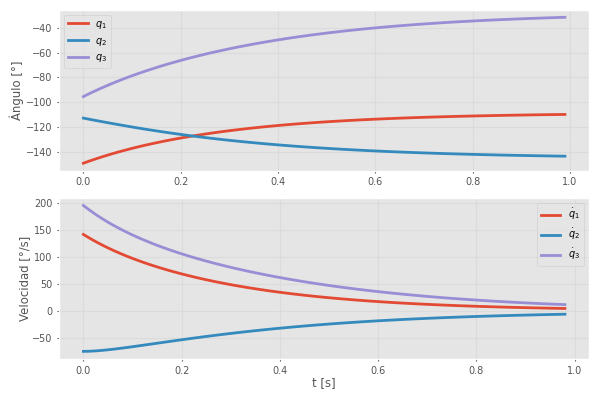

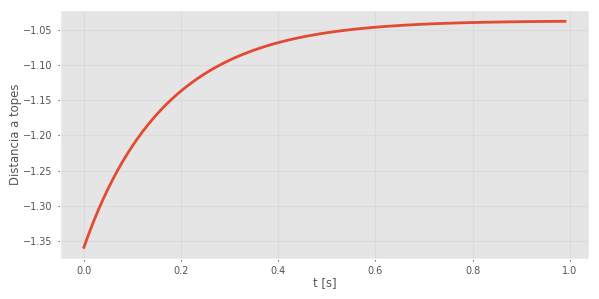

Animando 25 frames


In [125]:
# Vamos a movernos al mismo punto para observar la mejora en la manipulabilidad
# Para esto definimos el vector de diseño en el sentido del gradiente de la manipulabilidad  

from scipy.optimize import approx_fprime

alpha = 0.1

q_samples = []
w_samples = []

# Ejemplo
# La trayectoria que se venía trabajando no muestra una clara diferencia porque fuerza el eje 1 al límite
#pos_fin = pose_fin.t[0:2]
#q = q_ini

# Otro ejemplo
# No se fuerzan posiciones en las que el robot queda al límite
#pose = sm.SE3().Trans(0.5, 0.5, 0)
#q = robot.ikine_LM(pose).q
#pos_fin = sm.SE3().Trans(0.5, -0.5, 0).t[0:2]


# Otro ejemplo (descomentar)
# Mantengo el punto, pero busco una configuración con ejes más centrados
pos_fin = pose_ini.t[0:2]
q = q_ini

# Esta función de costo proteje el pero caso (la articulación más cercana al límite)
# Orientada a robustez
def cost_softmax(q):
    beta=10
    q_max = np.pi
    q_min = -np.pi
    q_mid = (q_max + q_min) / 2
    r = (q_max - q_min) / 2

    e = ((q - q_mid) / r)**2
    return -(1/beta) * np.log(np.sum(np.exp(beta * e)))

# Esta función de costo pesa qué tan lejos están todas las articulaciones de sus puntos centrales
# Orientada a una mejora global (optimización)
def cost_joint_limits(q):
    q_max = np.pi
    q_min = -np.pi
    q_mid = (q_max + q_min) / 2
    r = (q_max - q_min) / 2
    return -np.sum(((q - q_mid) / r)**2)

N = 100
for i in range(N):
    pose_act = robot.fkine(q)
    pos_act = pose_act.t[0:2]

    deltaX = pos_fin - pos_act
    dX = deltaX/(N-i)

    # Me quedo con las filas del  Jacobiano que dan vx, vy, wz
    J = robot.jacob0(q)[[0, 1], :]
    J_pinv = np.linalg.pinv(J)

    # gradiente de la manipulabilidad
    g = approx_fprime(q, cost_joint_limits, epsilon=1e-6)
    
    # proyector al nullspace
    Null_J_pinv = np.eye(3) - J_pinv @ J

    # pseudoinversa    
    dq = J_pinv @ dX + alpha * Null_J_pinv @ g 

    # incremento posición articular
    q = q + dq

    w_samples.append(cost_joint_limits(q))
    q_samples.append(q.copy())

print("Verificación POSE final alcanzada\n",robot.fkine(q))

w_samples = np.array(w_samples)
q_samples = np.array(q_samples)

robot.plot_curves(q_samples,w_samples,label="Distancia a topes")
robot.animate(q_samples,show_ellipse=True)